In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers, data_generation_gamma, contaminated_normal
from bayesian_dro.Bayesian_DRO_continuous import EPSILON_SET
from mis_dro.models import univariate_GaussianModel
from mis_dro.npl import Npl

/tmp/dcs-tmp.u1604520/ipykernel_760831/3046799791.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/"
experiment_dir_bdro = "/dcs/pg23/u1604520/misdro/results_kdro/"
# results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")
#results_other_dgps_df = pd.read_csv(experiment_dir / "results_patrick.csv", index_col="uuid")
#results_df = pd.concat([results_other_dgps_df, results_gamma_df])
dfs = []
# for dir in [experiment_dir, experiment_dir_bdro]:
for alg in ['mmd', 'bdro', 'kdro']: 
    for epsilon in EPSILON_SET:
        # if dir == experiment_dir:
        # if alg == 'kdro':
        if alg == 'kdro':
            dfs_k = []
            for i in range(5):
                if i == 0:
                    file_path = experiment_dir + f"{alg}_cont_exp_N900_ncert_200_cont_0.1_{epsilon}_fourier.csv"
                else:
                    file_path = experiment_dir + f"{alg}_cont_exp_N900_ncert_200_cont_0.1_{epsilon}_fourier_{i}.csv"
                df_ = pd.read_csv(file_path)
                dfs_k.append(df_)
            df = pd.concat(dfs_k, ignore_index=True)
            # file_path = experiment_dir + f"{alg}_cont_exp_N900_ncert_200_cont_0.1_{epsilon}_fourier.csv"
            # df = pd.read_csv(file_path)
        else:
            file_path = experiment_dir + f"{alg}_cont_exp_N900_ncert_200_cont_0.1_{epsilon}.csv"
            df = pd.read_csv(file_path)
            #f"kdro_cont_normal_N400_{epsilon}.csv"   #test_results_eps_{epsilon}.csv
        # else:
        # file_path = dir + f"bdro_exp_N100_ncert_20_{epsilon}.csv"
            # file_path = experiment_dir_bdro + f"{alg}_exp_N100_ncert_100_{epsilon}.csv"
        df['epsilon'] = epsilon
        # if dir == experiment_dir:
        # if alg == 'kdro':
        #     df['algorithm'] = 'mmd-dro'
        # else:
        #     df['algorithm'] = 'bdro'
        df['algorithm'] = alg
        dfs.append(df)
results_df = pd.concat(dfs, ignore_index=True)
# check the number of train/test observations is the same:
# assert len(results_df["num_observations"].unique()) == 1
# assert len(results_df["num_test_observations"].unique()) == 1
# num_observations = results_df["num_observations"]
# num_test_observations = results_df["num_test_observations"]
results_df

FileNotFoundError: [Errno 2] No such file or directory: '/dcs/pg23/u1604520/misdro/results_kdro/mmd_cont_exp_N900_ncert_200_cont_0.1_0.001.csv'

In [4]:
results_df = results_df[results_df['epsilon'] < 0.2]

In [5]:
gb = results_df.groupby(by=["algorithm", "epsilon"])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"]
})
df

mean_cost                 var_cost posterior_time  \
                        mean         var         mean           mean   
algorithm epsilon                                                      
bdro      0.001    45.406322  159.842765  1235.239765       0.000110   
          0.002    45.622457  156.144093  1215.134459       0.000110   
          0.005    46.384095  165.277441  1179.659560       0.000110   
          0.010    47.284362  177.419717  1138.669845       0.000110   
          0.020    48.645205  198.459790  1082.261630       0.000110   
          0.050    51.648340  241.866242   991.002920       0.000110   
          0.100    55.467415  312.766992   907.496517       0.000110   
          0.150    58.724169  378.519454   856.583397       0.000110   
kdro      0.001    39.015264   84.503609  1620.233303      36.892964   
          0.002    39.069818   84.383999  1611.542405      36.892964   
          0.005    39.198932   84.061784  1587.488817      36.892964   
          0.010    39.321779   83.630417  1557.389772      36.892964   
          0.020    39.552213   83.045894  1508.119395      36.892964   
          0.050    40.450599   81.471613  1380.559244      36.892964   
          0.100    42.191703   90.597496  1216.816252      36.892964   
          0.150    45.065520  117.362043  1040.622777      36.892964   
mmd       0.001    39.664974   82.832207  1475.441458       0.000221   
          0.002    39.763364   83.288958  1456.025230       0.000221   
          0.005    39.830772   83.320063  1456.006317       0.000221   
          0.010    39.862116   85.064337  1437.173764       0.000221   
          0.020    40.161208   87.411484  1389.334590       0.000221   
          0.050    41.109820   95.369355  1286.413888       0.000221   
          0.100    43.077817  109.116839  1138.107752       0.000221   
          0.150    45.984024  135.344042  1009.789298       0.000221   

                    solve_time   solution             
                          mean       mean        var  
algorithm epsilon                                     
bdro      0.001     701.682662  19.530800  36.680371  
          0.002     701.682662  19.713500  36.191092  
          0.005     701.682662  20.178200  38.020853  
          0.010     701.682662  20.717400  40.113751  
          0.020     701.682662  21.476600  43.437887  
          0.050     701.682662  23.049000  49.777177  
          0.100     701.682662  24.920900  58.567772  
          0.150     701.682662  26.410300  66.223225  
kdro      0.001    3277.036807  14.660542  14.543228  
          0.002    3277.036807  14.723699  14.757622  
          0.005    3277.036807  14.888054  15.065139  
          0.010    3277.036807  15.083906  15.414644  
          0.020    3277.036807  15.415204  16.054537  
          0.050    3277.036807  16.432804  18.575973  
          0.100    3277.036807  18.012278  23.415616  
          0.150    3277.036807  20.081048  29.362263  
mmd       0.001      69.613447  15.924125  16.242549  
          0.002      69.613447  16.002618  16.190916  
          0.005      69.613447  16.051023  16.683840  
          0.010      69.613447  16.139876  16.526239  
          0.020      69.613447  16.454754  17.016251  
          0.050      69.613447  17.291831  18.873203  
          0.100      69.613447  18.806334  22.070980  
          0.150      69.613447  20.663379  27.180698

In [3]:
def plot_dgp(df, dgp: str, axis, Nsamples):
    # get a dataframe for each posterior
    bayes_df = df.loc["bdro", :]
    kdro_df = df.loc['kdro', :]
    mmd_df = df.loc["mmd", :]

    # # mean of variances + variance of means
    bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
    kdro_bootstrap_var = kdro_df["var_cost"]["mean"] + kdro_df["mean_cost"]["var"]
    mmd_bootstrap_var = mmd_df["var_cost"]["mean"] + mmd_df["mean_cost"]["var"]

    # plot mean-variance trade-off
    axis.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="BDRO")
    axis.plot(kdro_bootstrap_var, kdro_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="BAS-DRO (MMD-NPL)")
    axis.plot(mmd_bootstrap_var, mmd_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="MMD-DRO")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}, {Nsamples} samples")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
        if i % 4 == 0:
            axis.text(bayes_bootstrap_var[epsilon], bayes_df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        if (i+2) % 4 == 0:
            axis.text(mmd_bootstrap_var[epsilon], mmd_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

# plot mean-variance trade-off for each DGP
# dgp_list = list(df.index.get_level_values("dgp").unique())
# nrows = int(np.ceil(len(dgp_list)/2.0))
# fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=False, sharey=False, figsize=(10,10))
# for i, dgp in enumerate(dgp_list):
#     row = int(np.floor(i / 2.0))
#     col = i % 2
#     plot_dgp(dgp, axes[row][col])

NameError: name 'df' is not defined

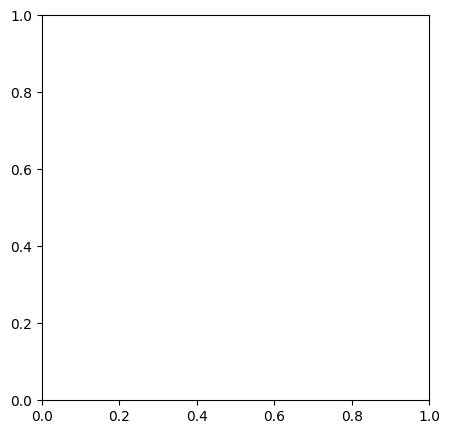

In [4]:
fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
plot_dgp(df, 'contaminated exponential', axis, 900)

In [5]:
N = 20
contamination_level = 0.1
delta = 0.2
opt_epsilon = 4*contamination_level + 2*(np.sqrt(1/N) + np.sqrt((2*(N-1))/(N*(N+1))) + np.sqrt(2*N*np.log(1/delta))/N)
print(opt_epsilon)

2.251154811890592


FileNotFoundError: [Errno 2] No such file or directory: '/dcs/pg23/u1604520/misdro/results_kdro/n100/bdro_cont_exp_N100_ncert_200_cont_0.2_0.001.csv'

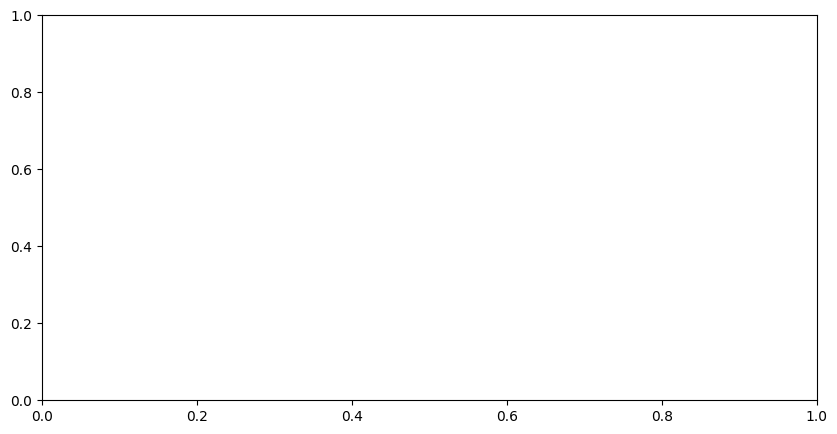

In [6]:
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/n100/"
experiment_dir_bdro = "/dcs/pg23/u1604520/misdro/results_kdro/n100/"
fig, axes = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(10,5))
N_values = [100] #, 400]
for i, N in enumerate(N_values):
    dfs = []
    for alg in ['bdro', 'kdro', 'mmd-dro']: #, 
        for epsilon in EPSILON_SET:
            if alg == 'bdro':
                file_path = experiment_dir_bdro + f"bdro_cont_exp_N100_ncert_200_cont_0.2_{epsilon}.csv" #f"kdro_cont_normal_N400_{epsilon}.csv"   #test_results_eps_{epsilon}.csv
            elif alg == 'kdro':
                file_path = experiment_dir + f"kdro_cont_exp_N100_ncert_200_cont_0.2_{epsilon}.csv"   # same exp just wrong file name
            else:
                file_path = experiment_dir + f"mmd_cont_exp_N{N}_ncert_200_cont_0.2_{epsilon}.csv" 
        
            df = pd.read_csv(file_path)
            df['epsilon'] = epsilon
            
            df['algorithm'] = alg
    
            dfs.append(df)
            
    results_df = pd.concat(dfs, ignore_index=True)
    results_df = results_df[results_df['epsilon'] < 0.2]
    gb = results_df.groupby(by=["algorithm", "epsilon"])
    df = gb.agg({
        "mean_cost": ["mean", "var"],
        "var_cost": ["mean"],
        "posterior_time": ["mean"],
        "solve_time": ["mean"],
        "solution": ["mean", "var"]
    })
    plot_dgp(df, 'contaminated_exp', axes, N)
plt.show()

In [7]:
from scipy.stats import truncnorm
b = 8
h = 3
L = 100

DGP_MEAN_TRUNCATED_NORMAL = 10
DGP_STD_TRUNCATED_NORMAL = 10

NUM_OBSERVATIONS = 20
sol_true = truncnorm.ppf(
        (b - 0) / (h + b), a=-DGP_MEAN_TRUNCATED_NORMAL / DGP_STD_TRUNCATED_NORMAL, b=np.inf, loc=DGP_MEAN_TRUNCATED_NORMAL, scale=DGP_STD_TRUNCATED_NORMAL
    )

In [8]:
sol_true

17.406341169581744

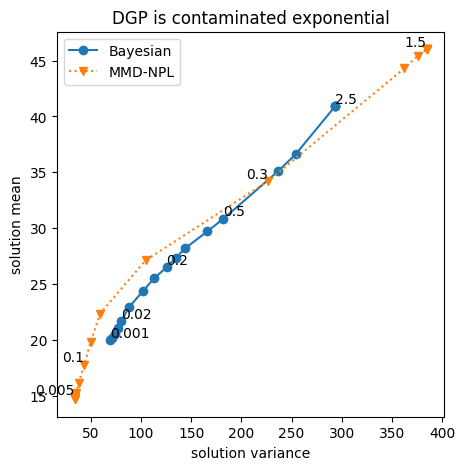

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
bayes_df = df.loc["bdro", :]
mmd_df = df.loc["mmd-dro", :]

bayes_bootstrap_var = bayes_df["solution"]["mean"] + bayes_df["solution"]["var"]
mmd_bootstrap_var = mmd_df["solution"]["mean"] + mmd_df["solution"]["var"]

# plot mean-variance trade-off
ax.plot(bayes_bootstrap_var, bayes_df["solution"]["mean"], marker='o', linestyle="solid", label="Bayesian")
    # axis.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
ax.plot(mmd_bootstrap_var, mmd_df["solution"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

# set title and label epsilon
ax.set_title("DGP is contaminated exponential")
ax.legend()
ax.set_xlabel("solution variance")
ax.set_ylabel("solution mean")
for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
    if i % 4 == 0:
        ax.text(bayes_bootstrap_var[epsilon], bayes_df["solution"]["mean"][epsilon], epsilon, ha='left', va='bottom')
    if (i+2) % 4 == 0:
        ax.text(mmd_bootstrap_var[epsilon], mmd_df["solution"]["mean"][epsilon], epsilon, ha='right', va='bottom')

Number of certifying points 

In [21]:
n_cert_values = [5, 20, 100]
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/ncert/"
dfs = []
for ncert in n_cert_values:
    for epsilon in EPSILON_SET:
        file_path = experiment_dir + f"kdro_cont_exp_N25_ncert_{ncert}_{epsilon}.csv" 
        df = pd.read_csv(file_path)
        df['epsilon'] = epsilon
        df['ncert'] = ncert
        # df['algorithm'] = 'mmd-dro'
        dfs.append(df)
results_df = pd.concat(dfs, ignore_index=True)
gb = results_df.groupby(by=["epsilon", 'ncert'])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"]
})
df

mean_cost                  var_cost posterior_time solve_time  \
                    mean          var         mean           mean       mean   
epsilon ncert                                                                  
0.001   5      41.003834   117.784595  1684.199796      32.541000   2.560638   
        20     41.238288   119.066943  1659.759387      32.278920   3.545263   
        100    41.318634   121.590004  1664.658881      32.801849  12.112839   
0.002   5      41.087965   117.306235  1672.867524      32.541000   2.560638   
        20     41.341995   121.610721  1656.832544      32.278920   3.545263   
        100    41.253841   119.852579  1659.091641      32.801849  12.112839   
0.005   5      41.192305   118.274521  1667.173785      32.541000   2.560638   
        20     41.422357   123.410382  1648.386198      32.278920   3.545263   
        100    41.336741   123.153104  1646.557138      32.801849  12.112839   
0.010   5      41.315094   120.924640  1651.155711      32.541000   2.560638   
        20     41.469058   123.949111  1633.622204      32.278920   3.545263   
        100    41.490302   125.408508  1627.286672      32.801849  12.112839   
0.020   5      41.714913   129.062359  1616.897580      32.541000   2.560638   
        20     41.655643   126.858609  1602.229897      32.278920   3.545263   
        100    41.742262   129.800215  1597.677647      32.801849  12.112839   
0.050   5      42.559821   144.225159  1519.930139      32.541000   2.560638   
        20     42.569369   141.069328  1520.909913      32.278920   3.545263   
        100    42.565052   144.751434  1513.241599      32.801849  12.112839   
0.100   5      44.437862   172.916281  1360.640872      32.541000   2.560638   
        20     44.121180   167.007537  1369.685444      32.278920   3.545263   
        100    44.154849   172.136849  1378.075904      32.801849  12.112839   
0.150   5      46.485514   221.810500  1242.751313      32.541000   2.560638   
        20     46.236259   211.297205  1244.325284      32.278920   3.545263   
        100    46.178371   213.678389  1256.521160      32.801849  12.112839   
0.200   5      50.372133   359.161230  1138.652296      32.541000   2.560638   
        20     48.823084   281.847149  1140.893070      32.278920   3.545263   
        100    48.633531   276.149477  1148.505206      32.801849  12.112839   
0.250   5      56.224584   621.433110  1022.402205      32.541000   2.560638   
        20     53.573467   478.986419  1046.847907      32.278920   3.545263   
        100    53.191598   450.281700  1045.892101      32.801849  12.112839   
0.300   5      69.199087  1480.577010   928.791549      32.541000   2.560638   
        20     65.210128  1096.601938   938.451080      32.278920   3.545263   
        100    62.760862   928.822934   934.661291      32.801849  12.112839   
0.400   5      77.222372  2028.784376   863.998834      32.541000   2.560638   
        20     76.191567  1937.636351   865.852057      32.278920   3.545263   
        100    75.465720  1837.984410   866.378494      32.801849  12.112839   
0.500   5      78.577871  2131.803885   855.303811      32.541000   2.560638   
        20     78.357900  2115.090425   857.421259      32.278920   3.545263   
        100    78.448960  2131.977418   858.489356      32.801849  12.112839   
1.000   5      78.761449  2179.258428   866.712358      32.541000   2.560638   
        20     78.761449  2179.258618   866.712359      32.278920   3.545263   
        100    78.761450  2179.258606   866.712360      32.801849  12.112839   
1.500   5      78.761444  2179.257768   866.712356      32.541000   2.560638   
        20     78.761449  2179.258621   866.712358      32.278920   3.545263   
        100    78.761450  2179.258626   866.712357      32.801849  12.112839   
2.000   5      78.761449  2179.258561   866.712359      32.541000   2.560638   
        20     78.761449  2179.258609   866.712357      32.278920   3.545263   
        100    

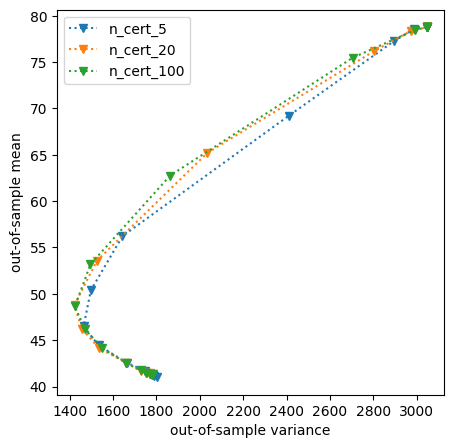

In [22]:
fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
for ncert in n_cert_values:
   dfn = df.xs(ncert, level='ncert')
   var = dfn["var_cost"]["mean"] + dfn["mean_cost"]["var"]
   axis.plot(var, dfn["mean_cost"]["mean"], marker="v", linestyle="dotted", label=f"n_cert_{ncert}")
axis.legend()
axis.set_xlabel("out-of-sample variance")
axis.set_ylabel("out-of-sample mean")

plt.show()

Tolerance level

In [11]:
def calculate_opt_tol(num_observations, kernel_bound, concentration_param, delta, inf_mmd):
    N = num_observations
    M = kernel_bound
    a = concentration_param 
    first_term = np.sqrt(M/N) 
    second_term = np.sqrt((2*M*(N-1)+ a*(a+1))/((a+N)*(a+N+1)))
    third_term = np.sqrt((M*a*(a+1))/((a+N)*(a+N+1)))
    fourth_term = np.sqrt(2*N*M*np.log(1/delta))/(a+N)
    return 2*(first_term+second_term+third_term+fourth_term) + inf_mmd

In [21]:
print(calculate_opt_tol(20,1,0,0.2,0))

1.851154811890592


### New

In [2]:
def process(experiment_dir, dgp, contamination):
    results_df = pd.read_csv(experiment_dir/ "results.csv", index_col=["uuid", "replication"])
    results_df = results_df.loc[(results_df["contamination"] == contamination) & (results_df["dgp"] == dgp)]
    
    gb = results_df.groupby(by=["algorithm", "epsilon", "inference"])
    agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    })
    return agg_df
     

In [3]:
def plot_df(df, dgp: str, algorithm: str, label: str, axis, marker=False):
    # get a dataframe for each posterior
    df = df.loc[algorithm, :]
    # # mean of variances + variance of means
    bootstrap_var = df["var_cost"]["mean"] + df["mean_cost"]["var"]
   

    # plot mean-variance trade-off
    axis.plot(bootstrap_var, df["mean_cost"]["mean"], marker='o', linestyle="solid", label=label)

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    if marker:
        for i, epsilon in enumerate(df.index.get_level_values("epsilon")):
            if i % 3 == 0:
                axis.text(bootstrap_var[epsilon], df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        # if (i+2) % 4 == 0:
        #     axis.text(empirical_bootstrap_var[epsilon], empirical_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

In [12]:
agg_df = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/N30_01_exp"), 'contaminated_exp', 0.1) 
agg_df
experiment_dir = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/N30_01_exp")
contamination = 0.1
dgp = 'contaminated_exp'
results_df = pd.read_csv(experiment_dir/ "results.csv", index_col=["uuid", "replication"])
results_df = results_df.loc[(results_df["contamination"] == contamination) & (results_df["dgp"] == dgp)]
results_df
# fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(12,5))
# plot_df(agg_df, 'exponential', 'dro_bas_mmd', 'DRO-RoBAS-0.1', axis)

mean_cost     var_cost  \
uuid                                 replication                            
d4d54a5c-0ca0-4c29-b787-4aab5a6ddb02 0             87.848879  5891.529808   
                                     1             59.487408   864.144733   
                                     2             70.326338  5218.875161   
                                     3             68.832745  2786.956377   
                                     4            102.485921  6866.085104   
...                                                      ...          ...   
2f484e7a-fd5b-4049-9b26-db4605c1fa45 195          246.925823  2512.845807   
                                     196          248.065296  2816.466297   
                                     197          245.888147  1833.937623   
                                     198          243.334750  2206.834234   
                                     199          238.408047  4494.985399   

                                                              solution  \
uuid                                 replication                         
d4d54a5c-0ca0-4c29-b787-4aab5a6ddb02 0              [33.9631901802826]   
                                     1             [30.93319010857702]   
                                     2            [26.280710749202917]   
                                     3            [36.222127656065645]   
                                     4             [34.01660683247049]   
...                                                                ...   
2f484e7a-fd5b-4049-9b26-db4605c1fa45 195           [99.99977965482908]   
                                     196           [99.99999501063486]   
                                     197           [99.99989802781198]   
                                     198            [99.9994025635821]   
                                     199           [99.99998442800279]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
d4d54a5c-0ca0-4c29-b787-4aab5a6ddb02 0            0.000444         0.002445   
                                     1            0.011496         0.004206   
                                     2            0.000711         0.002461   
                                     3            0.000762         0.002510   
                                     4            0.000764         0.002475   
...                                                    ...              ...   
2f484e7a-fd5b-4049-9b26-db4605c1fa45 195          0.013453         0.005607   
                                     196          0.000859         0.002624   
                                     197          0.000772         0.002588   
                                     198          0.000761         0.002614   
                                     199          0.000779         0.002615   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
d4d54a5c-0ca0-4c29-b787-4aab5a6ddb02 0                  0.006374  282.712575   
                                     1                  0.116416  280.131823   
                                     2                  0.008913  256.265140   
                                     3                  0.009495  265.363744   
                                     4                  0.005818  268.594348   
...                                                          ...         ...   
2f484e7a-fd5b-4049-9b26-db4605c1fa45 195                0.123886  278.358222   
                                     196                0.005135  263.468413   
                                     197                0.008492  277.658145   
                                     198                0.008908  278.226057   
                                     199                0.008450  269.972654   

                 

/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:895: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(s

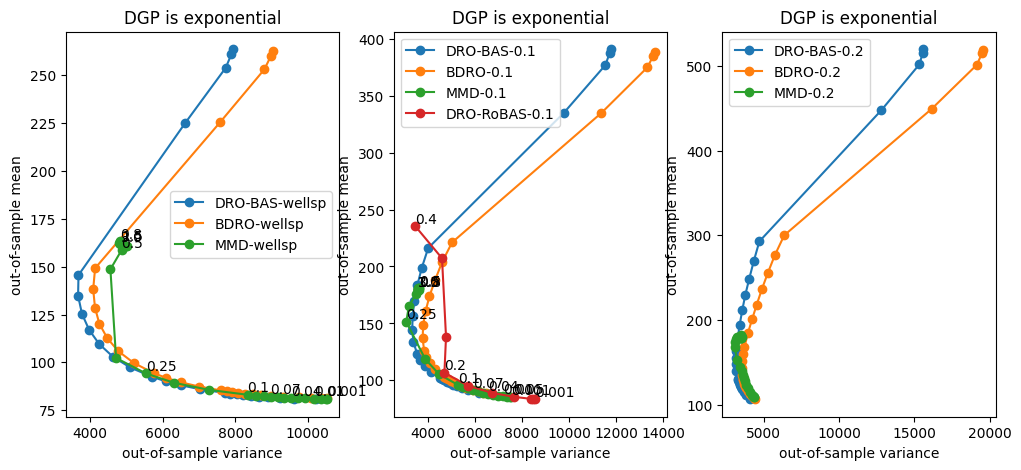

In [13]:
fig, axis = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=False, figsize=(12,5))
agg_df = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/N30_kl_exp"), 'contaminated_exp', 0.1)  #n400_mvn_kl_c
agg_df_emp = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/N30_emp_exp"), 'contaminated_exp', 0.1)
agg_df_mmd = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/N30_01_exp"), 'contaminated_exp', 0.1) 
plot_df(agg_df, 'exponential', 'kl_dro_bas', 'DRO-BAS-0.1', axis[1])
plot_df(agg_df, 'exponential', 'kl_bdro', 'BDRO-0.1', axis[1])
plot_df(agg_df_emp, 'exponential', 'empirical_mmd', 'MMD-0.1', axis[1], marker=True)
plot_df(agg_df_mmd, 'exponential', 'dro_bas_mmd', 'DRO-RoBAS-0.1', axis[1], marker=True)
agg_df = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/N30_kl_exp"), 'contaminated_exp', 0.2)  #cont_multivariate_normal
agg_df_emp = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/N30_emp_exp"), 'contaminated_exp', 0.2)
plot_df(agg_df, 'exponential', 'kl_dro_bas', 'DRO-BAS-0.2', axis[2])
plot_df(agg_df, 'exponential', 'kl_bdro', 'BDRO-0.2', axis[2])
plot_df(agg_df_emp, 'exponential', 'empirical_mmd', 'MMD-0.2', axis[2])
agg_df = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/N30_kl_exp"), 'contaminated_exp', 0.0)
agg_df_emp = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/N30_emp_exp"), 'contaminated_exp', 0.0)
plot_df(agg_df, 'exponential', 'kl_dro_bas', 'DRO-BAS-wellsp', axis[0])
plot_df(agg_df, 'exponential', 'kl_bdro', 'BDRO-wellsp', axis[0])
plot_df(agg_df_emp, 'exponential', 'empirical_mmd', 'MMD-wellsp', axis[0], marker=True)



# agg_df = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n400_mvn_kl_no_limit_minus"), 'cont_multivariate_normal', 0.1)
# plot_df(agg_df, 'multivariate normal', 'kl_dro_bas', 'DRO-BAS-0.1', axis[1])
# agg_df = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n400_mvn_kl_no_limit_minus"), 'cont_multivariate_normal', 0.05)
# plot_df(agg_df, 'multivariate normal', 'kl_dro_bas', 'DRO-BAS-0.05', axis[1])
# agg_df = process(Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n400_mvn_kl_no_limit_minus"), 'multivariate_normal', 0.0)
# plot_df(agg_df, 'multivariate normal', 'kl_dro_bas', 'DRO-BAS-wellsp', axis[1])



In [17]:
from mis_dro.bayes_conjugates import *
replication = 0
generator = np.random.default_rng(seed=replication)
inference = "bayes"
algorithm = "kl_bdro"
dim=5
num_posterior_samples = 20
num_likelihood_samples = 20
posterior = "multivariate_normal_known_cov"
# NOTE if contamination is specified, then only contaminate the training samples (not test samples)
data = cont_multivariate_normal(400, 0.0)
# 2. sample from the posterior
log_partition_constant = 0.0
if inference == "bayes":
    theta_prior = default_prior_params(posterior, dim=dim)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    if algorithm == "kl_dro_bas":
        num_posterior_samples = 1
        log_partition_constant = get_log_partition_constant(posterior, theta_posterior)
        theta_sample = derive_analytical_posterior_params(
            posterior, theta_posterior
        )
    else:
        theta_sample = sample_posterior(posterior, theta_posterior, num_likelihood_samples, generator=generator)

NameError: name 'cont_multivariate_normal' is not defined

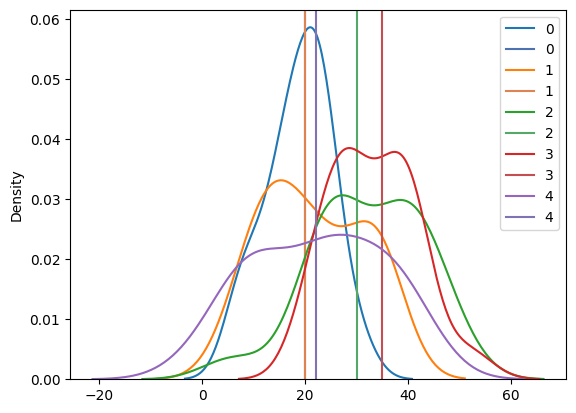

In [50]:
import seaborn as sns
pal = sns.color_palette("deep")
dgp_mean = np.array([20.0, 20.0, 30.0, 35.0, 22.0])
for i in range(dim):
    sns.kdeplot(theta_sample[:,i], label=f'{i}')
    plt.axvline(x=dgp_mean[i], label=f'{i}', color=pal[i])
plt.legend()

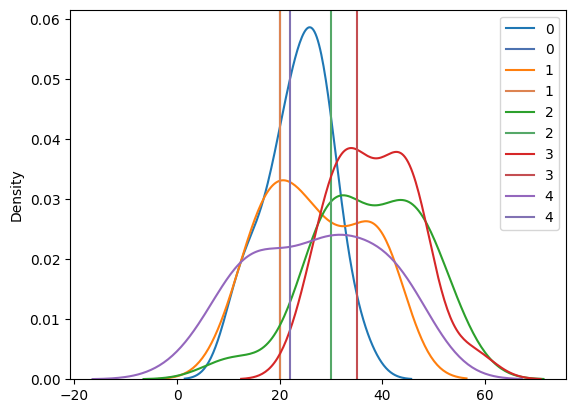

In [52]:
replication = 0
generator = np.random.default_rng(seed=replication)
inference = "bayes"
algorithm = "kl_bdro"
dim=5
num_posterior_samples = 20
num_likelihood_samples = 20
posterior = "multivariate_normal_known_cov"
# NOTE if contamination is specified, then only contaminate the training samples (not test samples)
data = cont_multivariate_normal(400, 0.05)
# 2. sample from the posterior
log_partition_constant = 0.0
if inference == "bayes":
    theta_prior = default_prior_params(posterior, dim=dim)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    if algorithm == "kl_dro_bas":
        num_posterior_samples = 1
        log_partition_constant = get_log_partition_constant(posterior, theta_posterior)
        theta_sample = derive_analytical_posterior_params(
            posterior, theta_posterior
        )
    else:
        theta_sample = sample_posterior(posterior, theta_posterior, num_likelihood_samples, generator=generator)

import seaborn as sns
pal = sns.color_palette("deep")
dgp_mean = np.array([20.0, 20.0, 30.0, 35.0, 22.0])
for i in range(dim):
    sns.kdeplot(theta_sample[:,i], label=f'{i}')
    plt.axvline(x=dgp_mean[i], label=f'{i}', color=pal[i])
plt.legend()

In [48]:
from scipy.stats import expon, gamma, norm, t, multivariate_normal
def cont_multivariate_normal(num_observations: int, contamination: float, random_state = None):
    
    if not random_state:
        random_state = np.random.default_rng()
    cont_size = int(np.floor(contamination * num_observations))
    n_real = num_observations - cont_size
    dgp_mean = np.array([20.0, 20.0, 30.0, 35.0, 22.0])
    dgp_mean_outl = dgp_mean + 100
    dgp_cov = (10**2)*np.eye(5)
    data = multivariate_normal.rvs(dgp_mean, dgp_cov, size=n_real, random_state=random_state)
    outl = multivariate_normal.rvs(dgp_mean_outl, dgp_cov, size=cont_size, random_state=random_state)
    data = np.concatenate((data, outl), axis=0)
    random_state.shuffle(data)  # shuffles the data in-place
    return data

cont_multivariate_normal(400, 0.0)

array([[27.27913797, 24.28819757, 20.38056094, 49.32016389, 26.23233117],
       [22.75701439, 14.74602865, 34.20249695, 35.35993616, 32.79456746],
       [19.74781746, 23.84996093, 15.46765172, 34.12740235,  4.5239829 ],
       ...,
       [28.0155666 , 35.61292986, 39.46073479, 38.09186004,  3.01998506],
       [25.36835408, 10.07645952, 23.79252082, 55.5117931 , 13.5381713 ],
       [20.13736594, 25.03323511, 30.04225137, 37.89827975, 23.65743482]])

In [19]:
# experiment_dir = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n80_exp_wellsp_0.1_all")
# experiment_dir_bayes = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n80_exp_wellsp_0.1_kl")
experiment_dir_cont = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n80_cont_exp")
# experiment_dir_bdro = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n80_exp_bdro_npl")
# assert experiment_dir.exists()
# results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
# results_df_bayes = pd.read_csv(experiment_dir_bayes / "results.csv", index_col=["uuid", "replication"])
results_df_cont = pd.read_csv(experiment_dir_cont / "results.csv", index_col=["uuid", "replication"])
# results_df_bdro = pd.read_csv(experiment_dir_bdro / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
# for _, row in results_df.iterrows():
#     if row["algorithm"] == "kl_bdro":
#         num_total_samples.append(row["num_likelihood_samples"] ** 2)
#     elif row["algorithm"] == "kl_dro_bas":
#         num_total_samples.append(row["num_likelihood_samples"])
# results_df["num_total_samples"] = num_total_samples

# NOTE filter by DGP
# results_df = results_df.loc[results_df["dgp"] == 'exponential']   #contaminated_exp contaminated_normal
# results_df_bayes = results_df_bayes.loc[results_df_bayes["dgp"] == 'exponential'] 
# results_df = results_df.loc[results_df["contamination"] == 0.1] 
# results_df_bayes = results_df_bayes.loc[results_df_bayes["contamination"] == 0.1] 
results_df_cont = results_df_cont.loc[results_df_cont["contamination"] == 0.05] 
# results_df_cont = results_df_cont[results_df_cont['epsilon'] < 0.4]
# results_df_bdro = results_df_bdro.loc[results_df_bdro["contamination"] == 0.1] 
# results_df_bdro = results_df_bdro[results_df_bdro['epsilon'] < 0.4]

results_df_cont

mean_cost     var_cost  \
uuid                                 replication                            
c2311af2-322c-4717-a39b-f736ada5b3e6 0             45.991286  2214.092405   
                                     1             28.789420   429.061643   
                                     2             35.308738  1687.700457   
                                     3             30.983170  1413.147230   
                                     4             50.315130  2930.662683   
...                                                      ...          ...   
0863b974-2a34-404d-a4e1-0f7c167ba91f 195           53.912195   482.031318   
                                     196          115.068361   704.116574   
                                     197          168.494162   731.653680   
                                     198           88.208147   551.708559   
                                     199          158.475657  1123.746350   

                                                              solution  \
uuid                                 replication                         
c2311af2-322c-4717-a39b-f736ada5b3e6 0            [14.003644455230635]   
                                     1              [12.8158054711998]   
                                     2            [11.320748789679254]   
                                     3            [12.260460635877791]   
                                     4            [13.655671714563907]   
...                                                                ...   
0863b974-2a34-404d-a4e1-0f7c167ba91f 195          [25.361200388614847]   
                                     196           [47.01190199664554]   
                                     197           [66.17849156792323]   
                                     198           [38.84662524287341]   
                                     199           [63.09053678414958]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
c2311af2-322c-4717-a39b-f736ada5b3e6 0            0.000471         0.001785   
                                     1            0.001379         0.003656   
                                     2            0.001382         0.002796   
                                     3            0.000953         0.003410   
                                     4            0.001144         0.003574   
...                                                    ...              ...   
0863b974-2a34-404d-a4e1-0f7c167ba91f 195          0.000527         0.002850   
                                     196          0.000548         0.002942   
                                     197          0.000544         0.002816   
                                     198          0.000529         0.002880   
                                     199          0.000519         0.002796   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
c2311af2-322c-4717-a39b-f736ada5b3e6 0                  0.005276   43.967476   
                                     1                  0.007255   42.072235   
                                     2                  0.006644   41.772385   
                                     3                  0.003660   39.494989   
                                     4                  0.005427   40.470825   
...                                                          ...         ...   
0863b974-2a34-404d-a4e1-0f7c167ba91f 195                0.001692    0.134476   
                                     196                0.001855    0.129550   
                                     197                0.001742    0.125964   
                                     198                0.002406    0.126757   
                                     199                0.001762    0.121643   

                 

In [20]:
# results_df_cont.loc[results_df_cont['algorithm'] == 'kl_bdro'].loc[results_df_cont['inference'] == "npl_mmd"]["algorithm"] = 'npl_bdro'
results_df_cont.loc[(results_df_cont['algorithm'] == 'kl_bdro') & (results_df_cont['inference'] == 'npl_mmd'), 'algorithm'] = 'npl_bdro'
results_df_cont[results_df_cont['algorithm'] == 'kl_dro_bas']

mean_cost     var_cost  \
uuid                                 replication                            
c10bfe38-52e9-4599-a0e7-73ae85f6731c 0                   inf     0.000000   
                                     1                   inf     0.000000   
                                     2                   inf     0.000000   
                                     3                   inf     0.000000   
                                     4                   inf     0.000000   
...                                                      ...          ...   
e1557c82-eae3-4c24-a373-d2ba73ee6327 195           84.538478   467.407623   
                                     196          102.361716   704.116574   
                                     197          138.195189   731.653680   
                                     198          105.361925   551.708559   
                                     199          165.803331  1123.746350   

                                                              solution  \
uuid                                 replication                         
c10bfe38-52e9-4599-a0e7-73ae85f6731c 0                           [inf]   
                                     1                           [inf]   
                                     2                           [inf]   
                                     3                           [inf]   
                                     4                           [inf]   
...                                                                ...   
e1557c82-eae3-4c24-a373-d2ba73ee6327 195           [36.64828420803155]   
                                     196           [42.77635349321093]   
                                     197          [56.078833837543826]   
                                     198          [44.564551148710024]   
                                     199           [65.53309480420157]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
c10bfe38-52e9-4599-a0e7-73ae85f6731c 0            0.000489         0.000108   
                                     1            0.000850         0.000174   
                                     2            0.000850         0.000168   
                                     3            0.000671         0.000170   
                                     4            0.000645         0.000167   
...                                                    ...              ...   
e1557c82-eae3-4c24-a373-d2ba73ee6327 195          0.000617         0.000138   
                                     196          0.000552         0.000135   
                                     197          0.000525         0.000135   
                                     198          0.000521         0.000141   
                                     199          0.000601         0.000156   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
c10bfe38-52e9-4599-a0e7-73ae85f6731c 0                  0.000045    0.000013   
                                     1                  0.000066    0.000021   
                                     2                  0.000066    0.000025   
                                     3                  0.000056    0.000023   
                                     4                  0.000060    0.000023   
...                                                          ...         ...   
e1557c82-eae3-4c24-a373-d2ba73ee6327 195                0.000049    0.128150   
                                     196                0.000048    0.132230   
                                     197                0.000050    0.134101   
                                     198                0.000049    0.127018   
                                     199                0.000055    0.090225   

                 

In [21]:
# gb = results_df_bdro.groupby(by=["algorithm", "epsilon", "inference"])
# agg_df = gb.agg({
#     "mean_cost": ["mean", "var"],
#     "var_cost": ["mean"],
#     # "posterior_time": ["mean"],
#     # "setup_time": ["mean"],
#     # "solve_time": ["mean"],
#     # "solution": ["mean", "var"],
# })
# agg_df

# gb = results_df_bayes.groupby(by=["algorithm", "epsilon", "inference"])
# agg_df_bayes = gb.agg({
#     "mean_cost": ["mean", "var"],
#     "var_cost": ["mean"],
#     # "posterior_time": ["mean"],
#     # "setup_time": ["mean"],
#     # "solve_time": ["mean"],
#     # "solution": ["mean", "var"],
# })
# agg_df_bayes

gb = results_df_cont.groupby(by=["algorithm", "epsilon", "inference"])
agg_df_cont = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    # "posterior_time": ["mean"],
    # "setup_time": ["mean"],
    # "solve_time": ["mean"],
    # "solution": ["mean", "var"],
})

# agg_dfs = pd.concat([agg_df, agg_df_cont])
# agg_df_bayes

In [22]:
agg_df_cont.loc["dro_bas_mmd", :]


mean_cost                 var_cost
                         mean         var         mean
epsilon inference                                     
0.001   npl_mmd     40.672992   54.559481  2809.067269
0.002   npl_mmd     40.661497   54.438313  2804.679862
0.005   npl_mmd     40.633990   53.888091  2780.896054
0.010   npl_mmd     40.623324   53.238291  2742.129827
0.020   npl_mmd     40.617408   51.942616  2675.876783
0.030   npl_mmd     40.627242   50.719274  2608.138421
0.040   npl_mmd     40.654393   49.523066  2551.020554
0.050   npl_mmd     40.716231   48.520155  2491.232108
0.060   npl_mmd     40.797262   47.578629  2430.978701
0.070   npl_mmd     40.873955   46.691884  2373.338612
0.080   npl_mmd     40.970219   45.709905  2320.369029
0.090   npl_mmd     41.090497   44.795790  2266.209884
0.100   npl_mmd     41.226127   44.263460  2209.966297
0.150   npl_mmd     42.246784   42.011278  1933.128497
0.200   npl_mmd     44.027354   43.058490  1659.566433
0.250   npl_mmd     47.196232   50.359725  1377.756711
0.300   npl_mmd     58.202199  136.915004   974.791155
0.400   npl_mmd    103.635595  846.303898   775.785579
0.500   npl_mmd    108.619962  916.209174   779.510262
0.600   npl_mmd    112.155624  995.860366   783.949152
0.700   npl_mmd    112.154300  996.893592   784.401871
0.800   npl_mmd    112.084365  964.880047   783.705740
0.900   npl_mmd    112.271054  975.782051   784.040431
1.000   npl_mmd    112.228071  972.043497   790.231390
1.500   npl_mmd    112.267259  976.886092   784.356825
2.000   npl_mmd    112.282581  968.176843   785.615949
2.500   npl_mmd    112.393340  966.885182   786.463784
3.000   npl_mmd    112.417439  964.449313   785.993158

In [23]:
def plot_dgp(df, dgp: str, axis):
    # get a dataframe for each posterior
    bayes_df = df.loc["kl_bdro", :]
    bas_kl_df = df.loc['kl_dro_bas', :]
    bas_df = df.loc['dro_bas_mmd', :]
    empirical_df = df.loc["empirical_mmd", :]
    bdro_npl_df = df.loc["npl_bdro", :]

    # # mean of variances + variance of means
    bdro_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
    bas_bootstrap_var = bas_kl_df["var_cost"]["mean"] + bas_kl_df["mean_cost"]["var"]
    robas_bootstrap_var = bas_df["var_cost"]["mean"] + bas_df["mean_cost"]["var"]
    empirical_bootstrap_var = empirical_df["var_cost"]["mean"] + empirical_df["mean_cost"]["var"]
    bdro_npl_bootstrap_var =bdro_npl_df["var_cost"]["mean"] + bdro_npl_df["mean_cost"]["var"]

    # plot mean-variance trade-off
    # axis.plot(bdro_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="BDRO")
    axis.plot(bas_bootstrap_var, bas_kl_df["mean_cost"]["mean"], marker='s', linestyle="solid", label="DRO-BAS")
    axis.plot(robas_bootstrap_var, bas_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="DRO-RoBAS")
    axis.plot(empirical_bootstrap_var, empirical_df["mean_cost"]["mean"], marker="+", linestyle="dotted", label="Empirical-MMD-DRO")
    axis.plot(bdro_npl_bootstrap_var, bdro_npl_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="BDRO-NPL")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    for i, epsilon in enumerate(empirical_df.index.get_level_values("epsilon")):
        if i % 4 == 0:
            axis.text(empirical_bootstrap_var[epsilon], empirical_df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        # if (i+2) % 4 == 0:
        #     axis.text(empirical_bootstrap_var[epsilon], empirical_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:895: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(s

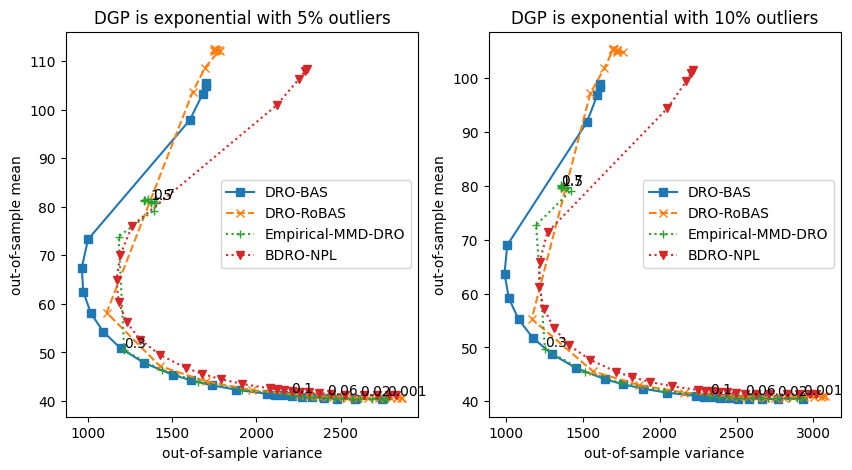

In [24]:
fig, axis = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, figsize=(10,5))
plot_dgp(agg_df_cont, 'exponential with 5% outliers', axis[0])
experiment_dir_cont = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n80_cont_exp")
results_df_cont = pd.read_csv(experiment_dir_cont / "results.csv", index_col=["uuid", "replication"])
results_df_cont = results_df_cont.loc[results_df_cont["contamination"] == 0.1] 
results_df_cont.loc[(results_df_cont['algorithm'] == 'kl_bdro') & (results_df_cont['inference'] == 'npl_mmd'), 'algorithm'] = 'npl_bdro'
results_df_cont[results_df_cont['algorithm'] == 'kl_dro_bas']

gb = results_df_cont.groupby(by=["algorithm", "epsilon", "inference"])
agg_df_cont = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
})
plot_dgp(agg_df_cont, 'exponential with 10% outliers', axis[1])


/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:895: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(s

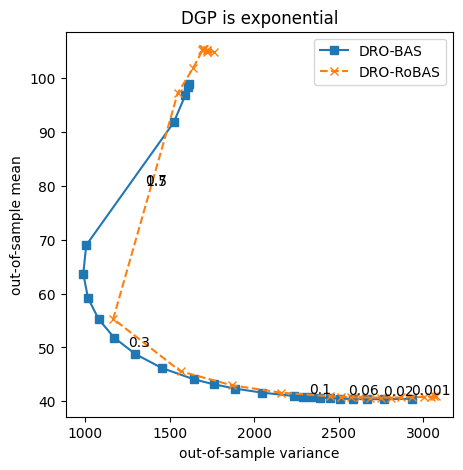

In [23]:
fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
plot_dgp(agg_df_cont, 'exponential', axis)

In [42]:
from mis_dro.dataset import *
from mis_dro.npl import *
replication = 0
dgp = "contaminated_exp"
num_observations = 80
dim = 1
contamination = 0.1
generator = np.random.default_rng(seed=replication)
# NOTE if contamination is specified, then only contaminate the training samples (not test samples)
data = sample_dgp(
    dgp, num_observations, dim=1, contamination=contamination, generator=generator
)

inference = 'npl_mmd'
likelihood = 'exponential'
num_posterior_samples = 30
lengthscale = -1

theta_sample = sample_npl(
    data,
    inference,
    likelihood,
    num_posterior_samples,
    seed=replication,
    lengthscale=lengthscale,
    generator=generator,
)

print(theta_sample)



[[0.04025156]
 [0.04420427]
 [0.03840147]
 [0.04219005]
 [0.04198128]
 [0.04013882]
 [0.04410151]
 [0.03570524]
 [0.04710088]
 [0.04718769]
 [0.05309139]
 [0.03506696]
 [0.03948143]
 [0.04849677]
 [0.04020087]
 [0.03791118]
 [0.03553534]
 [0.03054745]
 [0.03972579]
 [0.02637912]
 [0.04048656]
 [0.03524866]
 [0.03567098]
 [0.04148116]
 [0.04199565]
 [0.03633547]
 [0.03471749]
 [0.03519255]
 [0.04630981]
 [0.03369017]]


In [17]:
1/theta_sample

array([[24.84375783],
       [22.6222498 ],
       [26.04066825],
       [23.70226928],
       [23.82013821],
       [24.91353873],
       [22.67495838],
       [28.00709651],
       [21.23102697],
       [21.1919672 ],
       [18.83544731],
       [28.51686871],
       [25.32836623],
       [20.61993036],
       [24.87508264],
       [26.37744451],
       [28.14099633],
       [32.73595812],
       [25.17256139],
       [37.9087771 ],
       [24.69955636],
       [28.36987202],
       [28.03399305],
       [24.10733248],
       [23.81199148],
       [27.52131576],
       [28.80392381],
       [28.41510319],
       [21.59369548],
       [29.6822508 ]])

In [8]:
experiment_dir = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n80_studentt_missp")
experiment_dir_bayes = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n80_studentt_missp_kl")
experiment_dir_robas = Path('/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/n80_studentt_missp_robas')
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
results_df_bayes = pd.read_csv(experiment_dir_bayes / "results.csv", index_col=["uuid", "replication"])
results_df_robas = pd.read_csv(experiment_dir_robas / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
# for _, row in results_df.iterrows():
#     if row["algorithm"] == "kl_bdro":
#         num_total_samples.append(row["num_likelihood_samples"] ** 2)
#     elif row["algorithm"] == "kl_dro_bas":
#         num_total_samples.append(row["num_likelihood_samples"])
# results_df["num_total_samples"] = num_total_samples

# NOTE filter by DGP
results_df = results_df.loc[results_df["dgp"] == 'student_t']   #contaminated_exp contaminated_normal
results_df_bayes = results_df_bayes.loc[results_df_bayes["dgp"] == 'student_t'] 

# results_df = results_df[results_df['epsilon'] < 0.3]


gb = results_df.groupby(by=["algorithm", "epsilon", "inference"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    # "posterior_time": ["mean"],
    # "setup_time": ["mean"],
    # "solve_time": ["mean"],
    # "solution": ["mean", "var"],
})


gb = results_df_bayes.groupby(by=["algorithm", "epsilon", "inference"])
agg_df_bayes = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    # "posterior_time": ["mean"],
    # "setup_time": ["mean"],
    # "solve_time": ["mean"],
    # "solution": ["mean", "var"],
})
# print(agg_df_bayes)

gb = results_df_robas.groupby(by=["algorithm", "epsilon", "inference"])
agg_df_robas = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    # "posterior_time": ["mean"],
    # "setup_time": ["mean"],
    # "solve_time": ["mean"],
    # "solution": ["mean", "var"],
})

agg_dfs = pd.concat([agg_df, agg_df_bayes, agg_df_robas])

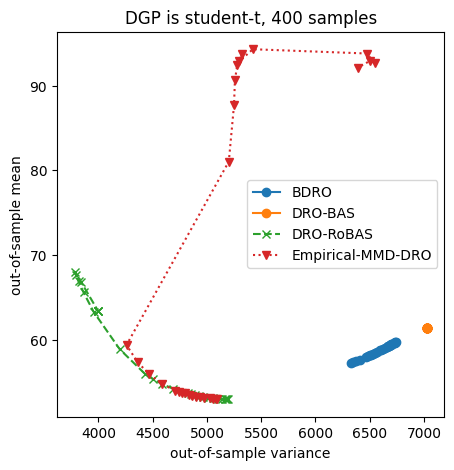

In [9]:
fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
plot_dgp(agg_dfs, 'student-t', axis, 400)

In [18]:
agg_dfs.loc['kl_dro_bas', :]

mean_cost                 var_cost
                        mean         var         mean
epsilon inference                                    
0.001   bayes            inf         NaN     0.000000
0.002   bayes            inf         NaN     0.000000
0.005   bayes            inf         NaN     0.000000
0.010   bayes            inf         NaN     0.000000
0.020   bayes      61.443562  165.229669  6861.624225
0.030   bayes      61.443314  165.228374  6861.596279
0.040   bayes      61.443141  165.227570  6861.576585
0.050   bayes      61.443004  165.226929  6861.561121
0.060   bayes      61.442871  165.226362  6861.545870
0.070   bayes      61.442747  165.225617  6861.531874
0.080   bayes      61.442649  165.225177  6861.520728
0.090   bayes      61.442551  165.224703  6861.509437
0.100   bayes      61.442462  165.224396  6861.499547
0.150   bayes      61.442077  165.222654  6861.455843
0.200   bayes      61.441751  165.221345  6861.419048
0.250   bayes      61.441457  165.219899  6861.385742
0.300   bayes      61.441199  165.218743  6861.356387
0.400   bayes      61.440748  165.216741  6861.305565
0.500   bayes      61.440355  165.214845  6861.260929
0.600   bayes      61.440001  165.213069  6861.221035
0.700   bayes      61.439674  165.211402  6861.184142
0.800   bayes      61.439375  165.209825  6861.150333
0.900   bayes      61.439097  165.208328  6861.119022
1.000   bayes      61.438839  165.206952  6861.089831
1.500   bayes      61.437787  165.201271  6860.970154
2.000   bayes      61.437078  165.197695  6860.888680
2.500   bayes      61.436626  165.195603  6860.836612
3.000   bayes      61.436347  165.194355  6860.804156

In [55]:
from scipy.stats import expon, norm
def data_generation_outliers(
    num_observations: int,
    contamination: float,
    random_state= None,
):
    """A contaminated exponential data-generating process (DGP)

    Args:
        num_observations: Number of observations from DGP
        contamination: Ratio of contaminated observations (outliers)
        random_state: A numpy random generator, if provided

    Notes:
        Shuffles data to ensure anomalies are not grouped together
    """
    if not random_state:
        random_state = np.random.default_rng()
    cont_size = int(np.floor(contamination * num_observations))
    n_real = num_observations - cont_size
    data = expon.rvs(scale=20, size=n_real, random_state=random_state)
    # outl = expon.rvs(scale=70, size=cont_size, random_state=random_state) #norm.rvs(loc=100, scale=0.5, size=cont_size, random_state=random_state) + 100
    outl = norm.rvs(loc=100, scale=0.5, size=cont_size, random_state=random_state)
    data = np.concatenate((data, outl), axis=0)
    random_state.shuffle(data)  # shuffles the data in-place
    return data

In [58]:
d = data_generation_outliers(80, 0.1)
d1 = data_generation_outliers(80, 0.0)

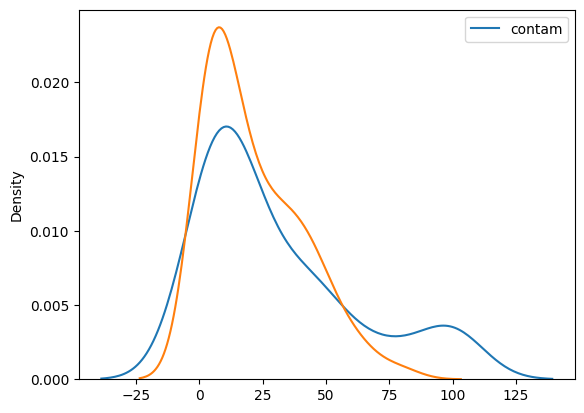

In [59]:
import seaborn as sns
sns.kdeplot(d, label='contam')
sns.kdeplot(d1)
plt.legend()

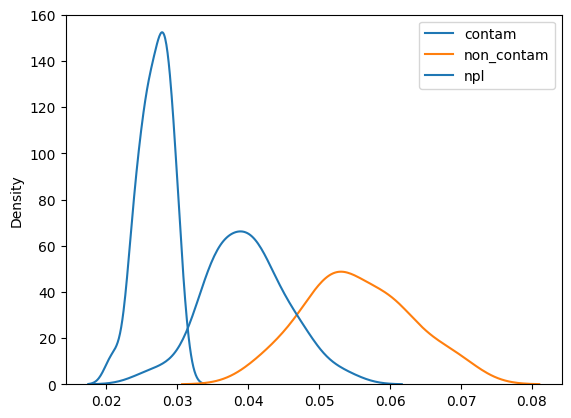

In [49]:
import scipy as sp
data = d
alpha_prior, beta_prior = 1, 1
prior_params = (alpha_prior, beta_prior)
alpha_prior, beta_prior = prior_params
alpha_posterior = alpha_prior + data.shape[0]
beta_posterior = beta_prior + np.sum(data)
post_params = (alpha_posterior, beta_posterior)

alpha_post, beta_post = post_params
post = sp.stats.gamma.rvs(
    a=alpha_post,
    scale=1 / beta_post,
    size=num_posterior_samples,
    random_state=generator,
)

data = d1
alpha_prior, beta_prior = 1, 1
prior_params = (alpha_prior, beta_prior)
alpha_prior, beta_prior = prior_params
alpha_posterior = alpha_prior + data.shape[0]
beta_posterior = beta_prior + np.sum(data)
post_params = (alpha_posterior, beta_posterior)

alpha_post, beta_post = post_params
post1 = sp.stats.gamma.rvs(
    a=alpha_post,
    scale=1 / beta_post,
    size=num_posterior_samples,
    random_state=generator,
)

sns.kdeplot(post, label='contam')
sns.kdeplot(post1, label='non_contam')
sns.kdeplot(theta_sample, label='npl')
plt.legend()



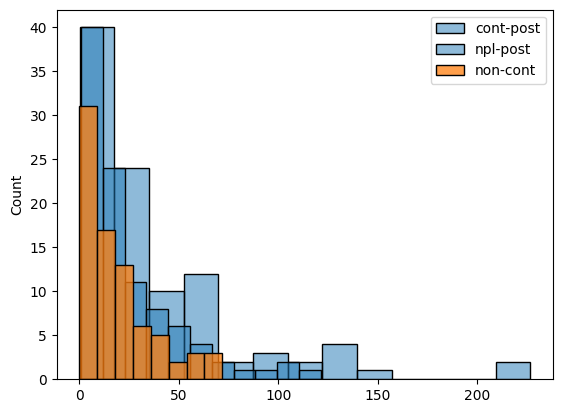

In [54]:
num_likelihood_samples = 100
data_from_post = sp.stats.expon.rvs(
                scale=1 / post.mean(),
                size=(num_likelihood_samples, dim),
                random_state=generator,
            )
data_from_post1 = sp.stats.expon.rvs(
                scale=1 / post1.mean(),
                size=(num_likelihood_samples, dim),
                random_state=generator,
            )
data_from_npl = sp.stats.expon.rvs(scale=1 / theta_sample.mean(),
                size=(num_likelihood_samples, dim),
                random_state=generator,
            )
sns.histplot(data_from_post, label='cont-post')
# sns.histplot(data_from_post1, label='non-cont-post')
sns.histplot(data_from_npl, label='npl-post', color='grey')
# sns.histplot(d, label='cont')
sns.histplot(d1, label='non-cont')
plt.legend()